In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
columns  = [
    "unit_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3"
]

sensor_columns= [f"sensor_{i}" for i in range(1,22)]

columns.extend(sensor_columns)

print("Numbers of columns:",len(columns))
                 

Numbers of columns: 26


In [3]:
#Loading traing data 

train_df = pd.read_csv(
     "../data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

print("Training Data shape:",train_df.shape)

Training Data shape: (20631, 26)


In [4]:
max_cycle = train_df.groupby("unit_id")["cycle"].max()

train_df["RUL"] = train_df.apply(
    lambda row:max_cycle[row["unit_id"]] - row["cycle"],
    axis = 1
)

train_df.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0


In [5]:
train_df[["unit_id" , "cycle" , "RUL"]].head()

,unit_id,cycle,RUL
0,1,1,191.0
1,1,2,190.0
2,1,3,189.0
3,1,4,188.0
4,1,5,187.0


In [6]:
print(train_df["RUL"].describe())

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


In [7]:
print("Minimum Data",train_df["RUL"].min())
print("Maximum Data",train_df["RUL"].max())

Minimum Data 0.0
Maximum Data 361.0


In [8]:
#EDA Understanding RUL
#RUL distribution

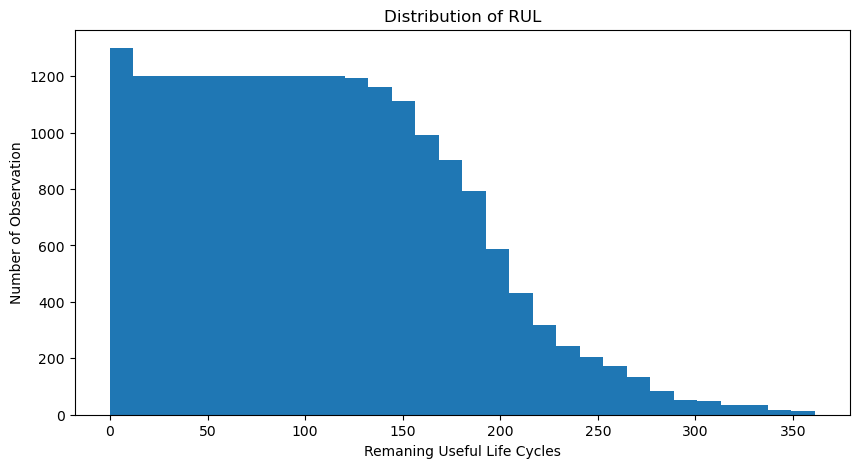

In [9]:
#RUL Distribuiton
plt.figure(figsize = (10,5))

plt.hist(
    train_df["RUL"],
    bins = 30 
)

plt.xlabel("Remaning Useful Life Cycles")
plt.ylabel("Number of Observation")
plt.title("Distribution of RUL")

plt.show()

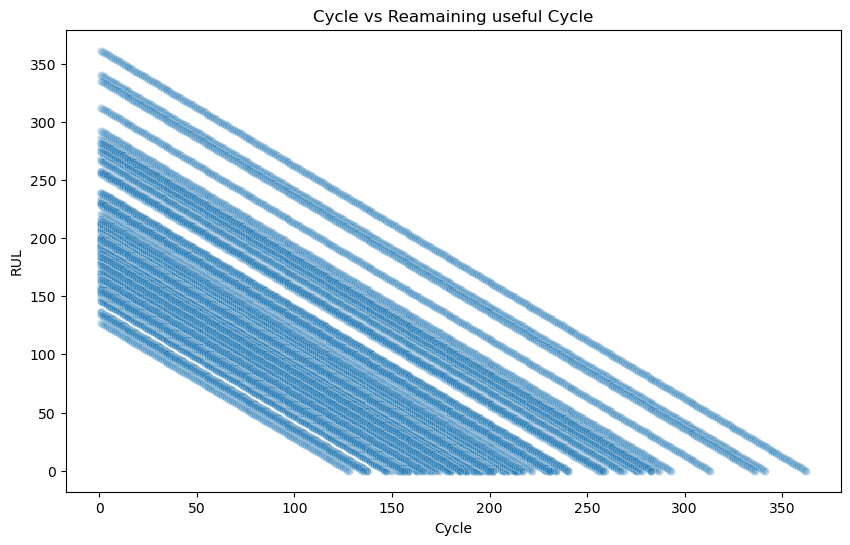

In [10]:
#RUL vs Cycle
plt.figure(figsize= (10,6))

sns.scatterplot(
    data= train_df,
    x = "cycle",
    y = "RUL",
    alpha = 0.3
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("Cycle vs Reamaining useful Cycle")

plt.show()

In [11]:
#in above scatter plot we obseve that as the number of cycle increases the RUL decreases or goes to negative 

In [12]:
#EDA Engine Degradation

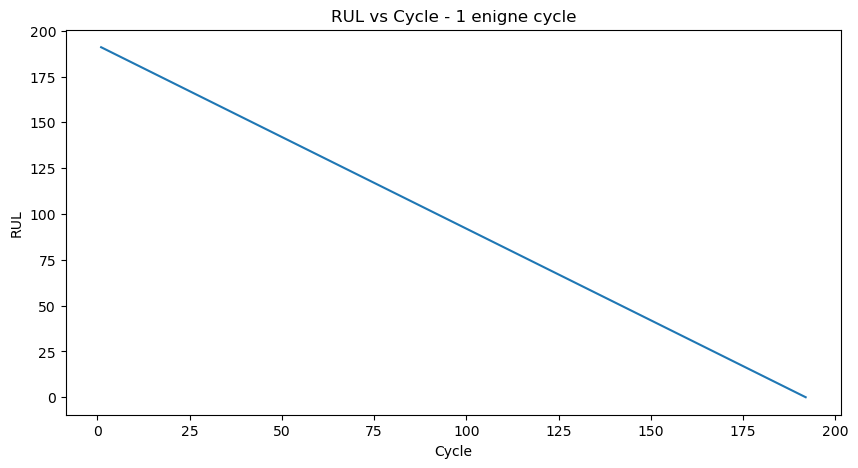

In [13]:
#plot RUL for one engine 

engine_1 = train_df[train_df["unit_id"]==1]

plt.figure(figsize=(10,5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"]
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL vs Cycle - 1 enigne cycle")
plt.show()

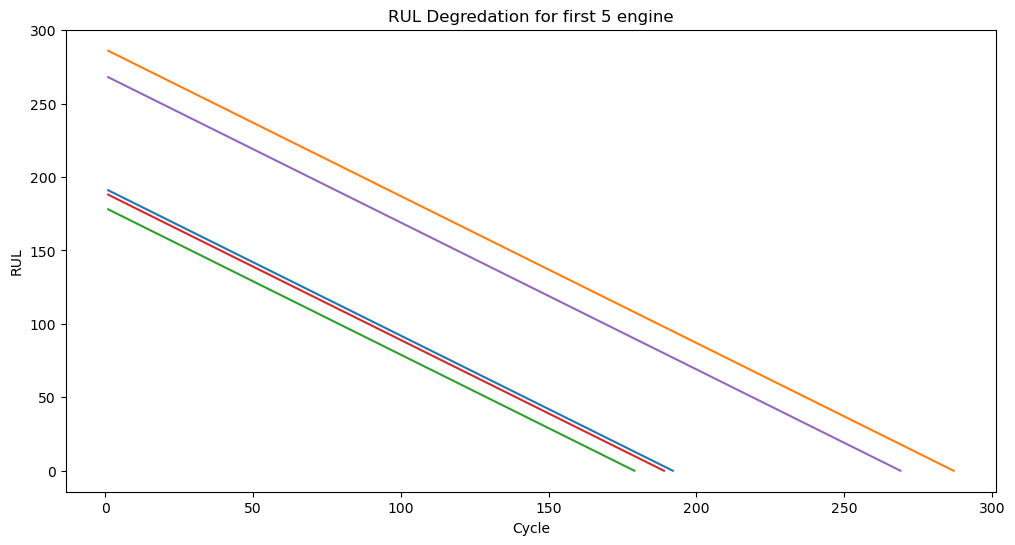

In [14]:
#multiple engine ploting 

plt.figure(figsize = (12,6))

for engine_id in [1 ,2 ,3, 4, 5]:

    engine_data = train_df[train_df["unit_id"] == engine_id]

    plt.plot(
    engine_data["cycle"],
    engine_data["RUL"],
    label = f"Engine {engine_id}"
    )

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL Degredation for first 5 engine")

plt.show()

In [15]:
#this help us to understand that every engine has diffrent lifetime 

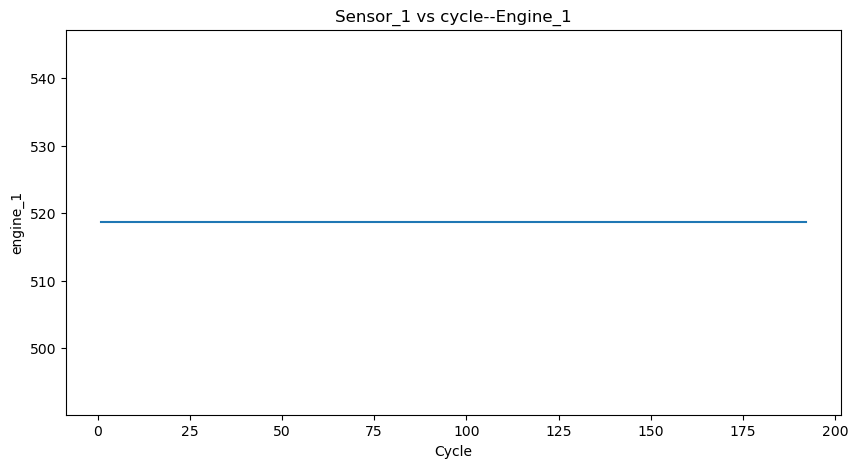

In [26]:
#Sensor Behavior
#sensor1 vs cycle 

engine_1 = train_df[train_df["unit_id"] ==1]

plt.figure(figsize=(10,5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_1"]
)

plt.xlabel("Cycle")
plt.ylabel("engine_1")
plt.title("Sensor_1 vs cycle--Engine_1")

plt.show()


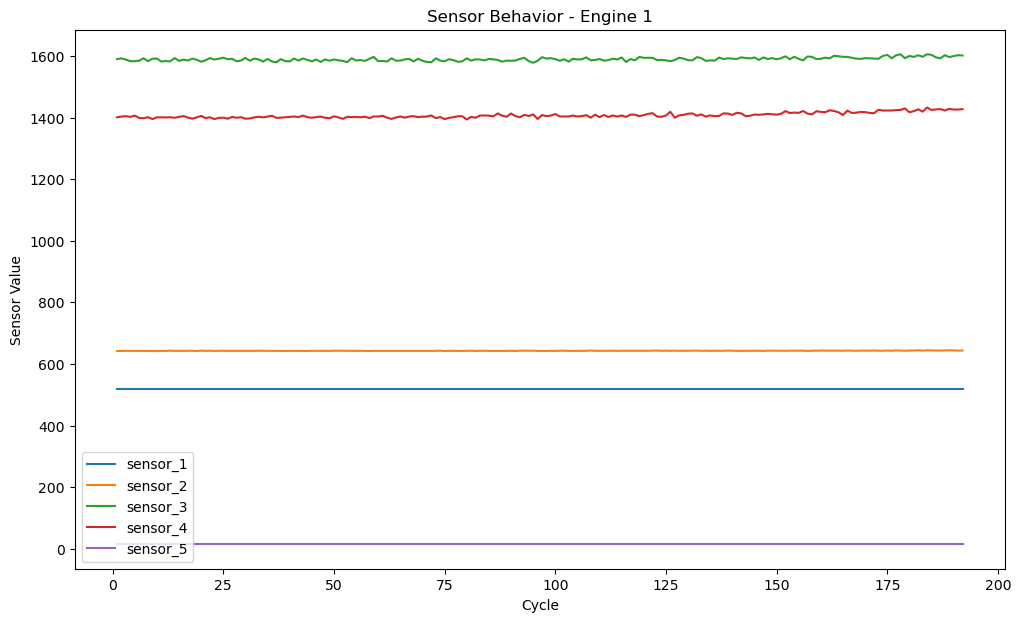

In [28]:
#Plot several sensor
# Instead of plotting all 21 sensors at once, start with the first 5.

plt.figure(figsize=(12,7))

for sensor in sensor_columns[:5]:

    plt.plot(
        engine_1["cycle"],
        engine_1[sensor],
        label = sensor
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor Behavior - Engine 1")
plt.legend()
plt.show()

In [30]:
#EDA Part 4 — Sensor correlation with RUL

sensor_rul_corr = train_df[sensor_columns + ["RUL"]].corr()["RUL"]

sensor_rul_corr = sensor_rul_corr.drop("RUL")

sensor_rul_corr = sensor_rul_corr.sort_values()

print(sensor_rul_corr)

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


Text(0.5, 1.0, 'Senor corr with RUL')

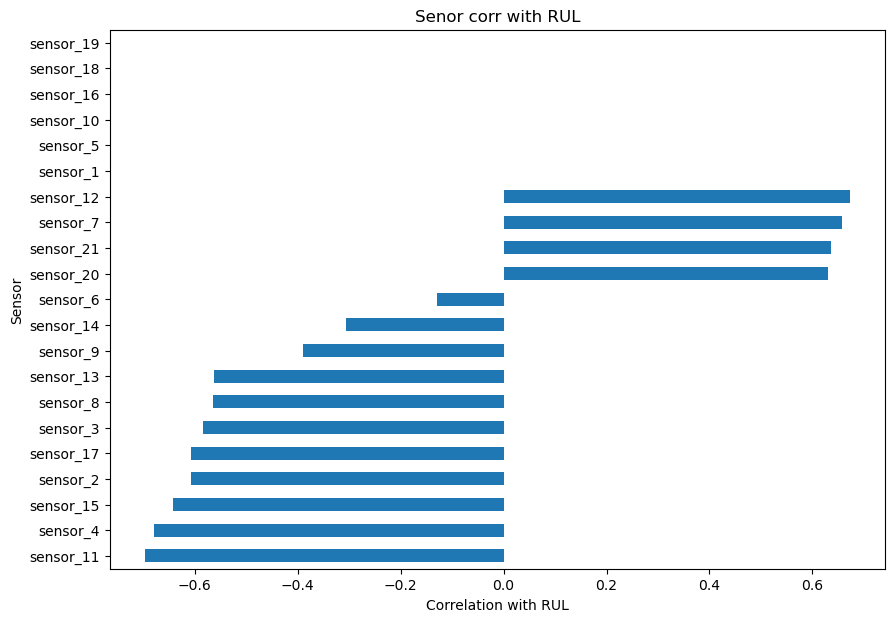

In [33]:
#Visualize sensor

plt.figure(figsize = (10,7))

sensor_rul_corr.plot(
    kind = 'barh')

plt.xlabel("Correlation with RUL")
plt.ylabel("Sensor")
plt.title("Senor corr with RUL")

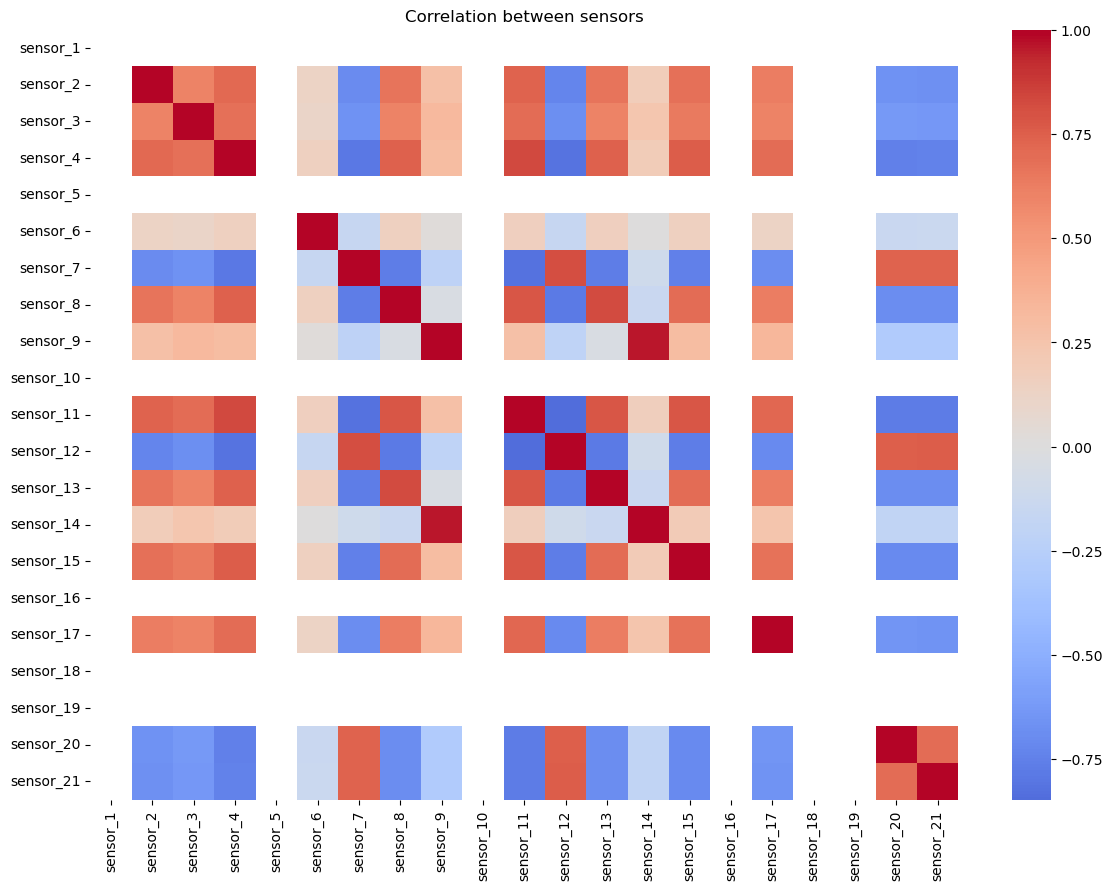

In [37]:
# EDA Part 5 — Sensor correlation matrix

plt.figure(figsize=(14,10))

correlation_matrix = train_df[sensor_columns].corr()

sns.heatmap(
    correlation_matrix,
    cmap = 'coolwarm',
    center = 0
)

plt.title("Correlation between sensors")
plt.show()

In [40]:
# EDA Part 6 — Operating settings
settings = ["setting_1" , "setting_2" , "setting_3"]

train_df[settings].describe()

,setting_1,setting_2,setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


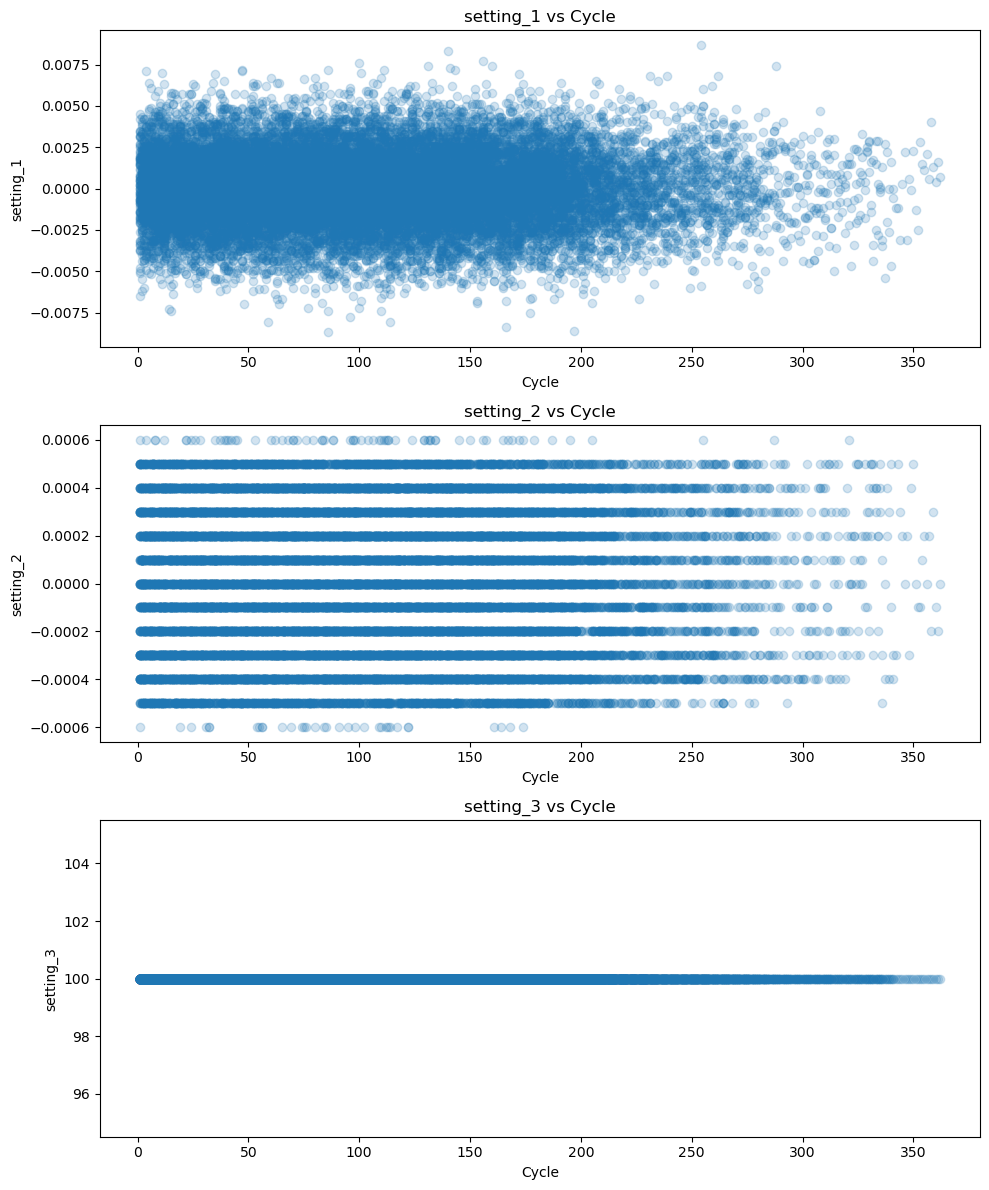

In [46]:
# EDA Part 6 — Operating settings

fig , axes = plt.subplots(3,1, figsize=(10,12))

for i , setting in enumerate(settings):
    axes[i].scatter(
        train_df["cycle"],
        train_df[setting],
        alpha = 0.2
    )

    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel(setting)
    axes[i].set_title(f"{setting} vs Cycle")

plt.tight_layout()
plt.show()
    

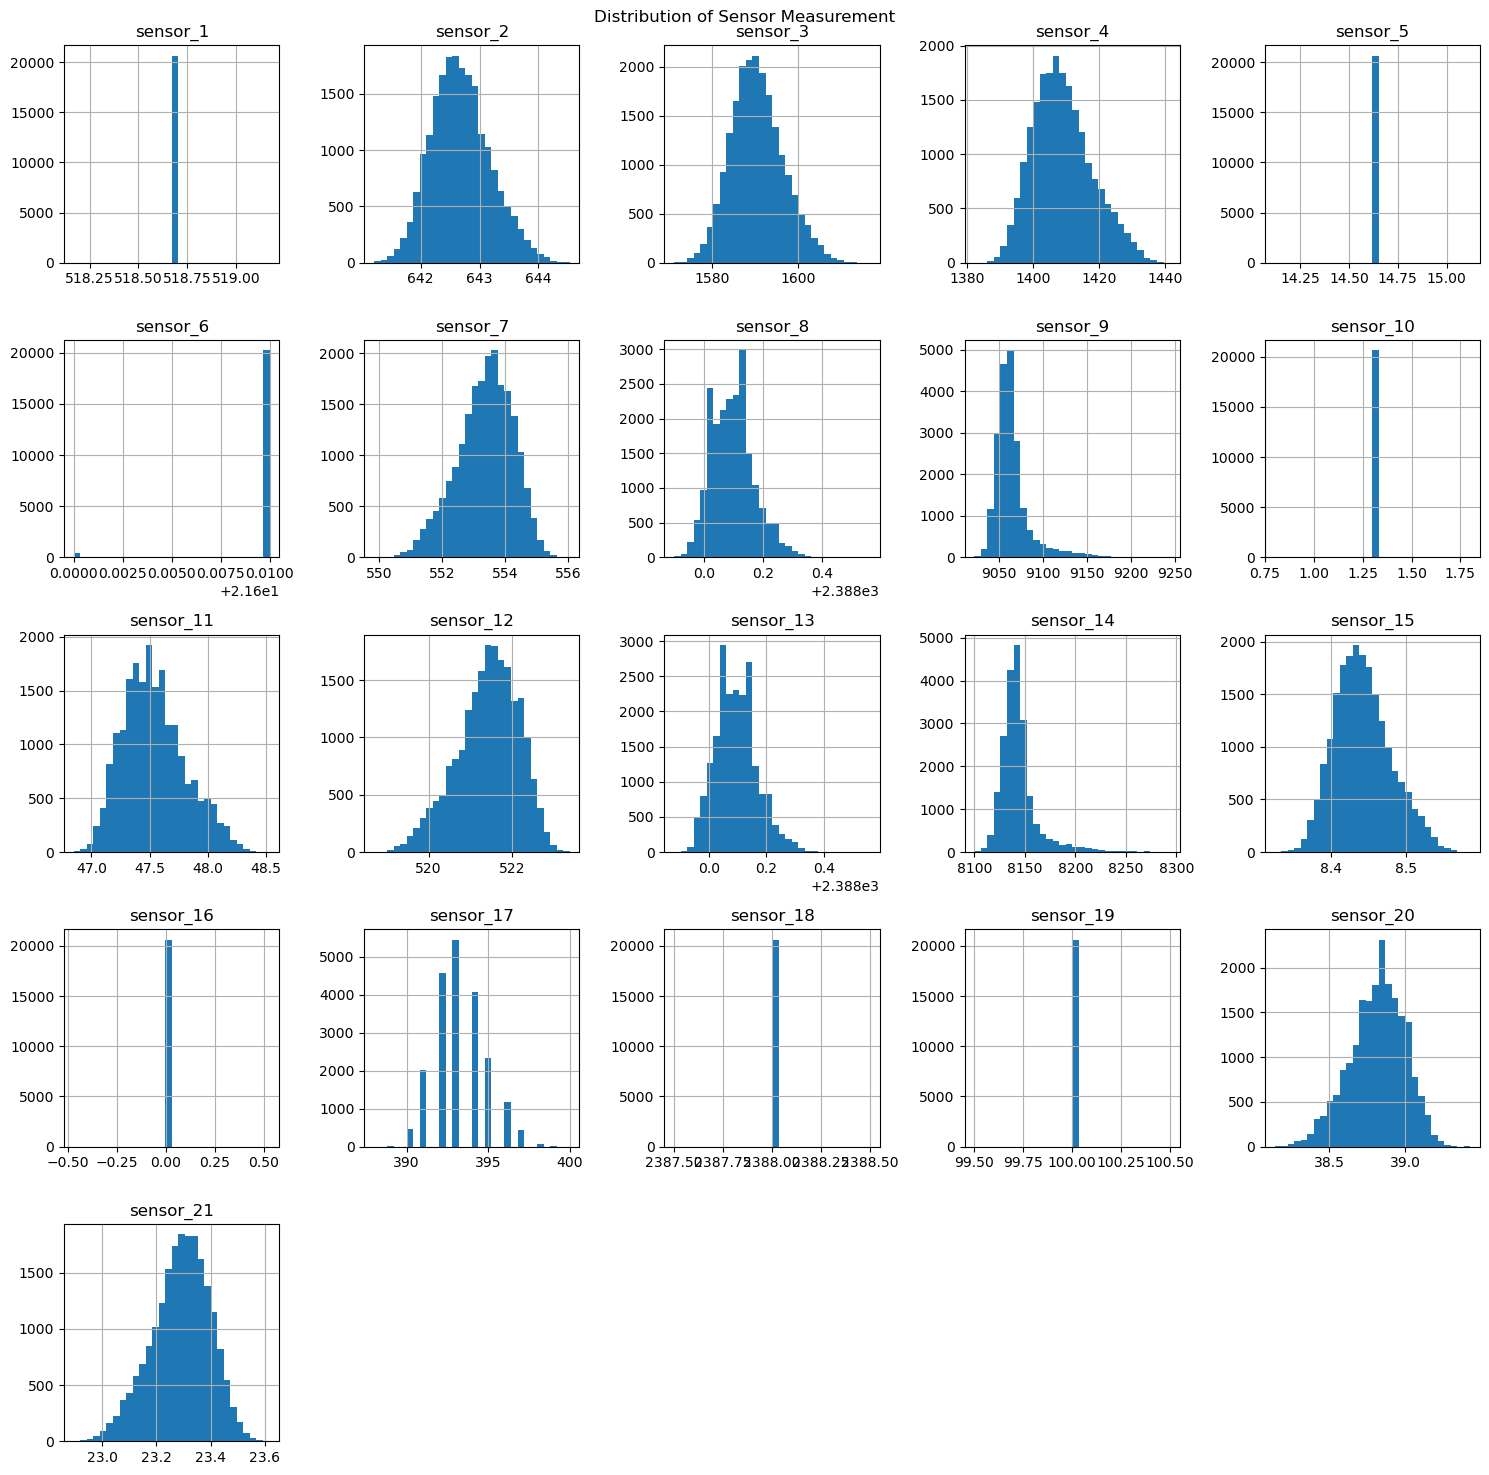

In [49]:
#EDA Part 7 — Sensor distributions

train_df[sensor_columns].hist(
    figsize=(15,15),
    bins = 30
)

plt.suptitle("Distribution of Sensor Measurement")

plt.tight_layout()
plt.show()

In [50]:
 #EDA Part 8 — Sensors with low variation

sensor_std = train_df[sensor_columns].std()

sensor_std = sensor_std.sort_values()

print(sensor_std)

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


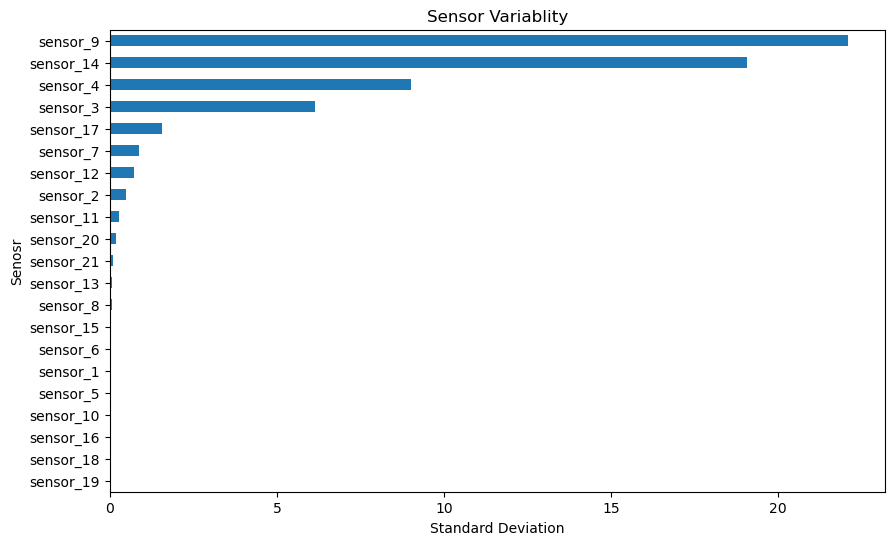

In [51]:
plt.figure(figsize=(10,6))

sensor_std.plot(
    kind="barh")

plt.xlabel("Standard Deviation")
plt.ylabel("Senosr")
plt.title("Sensor Variablity")

plt.show()

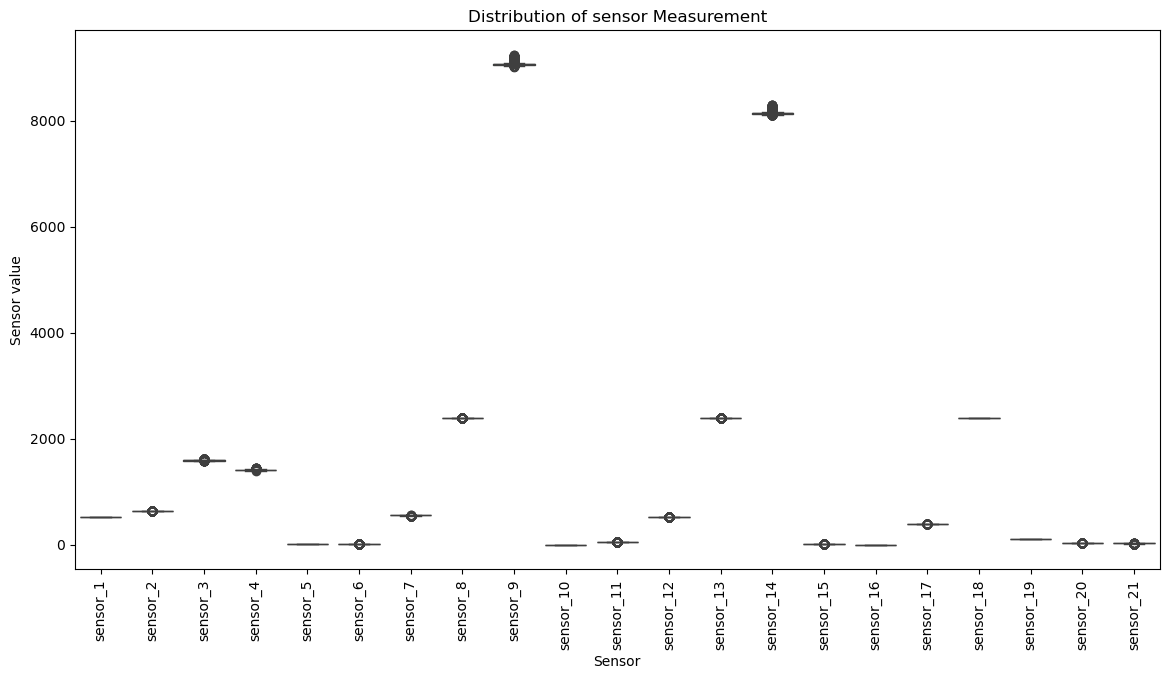

In [53]:
#Boxplot

plt.figure(figsize=(14,7))

sns.boxplot(
    data = train_df[sensor_columns]
)
plt.xticks(rotation=90)

plt.title("Distribution of sensor Measurement")

plt.xlabel("Sensor")
plt.ylabel("Sensor value")
plt.show()

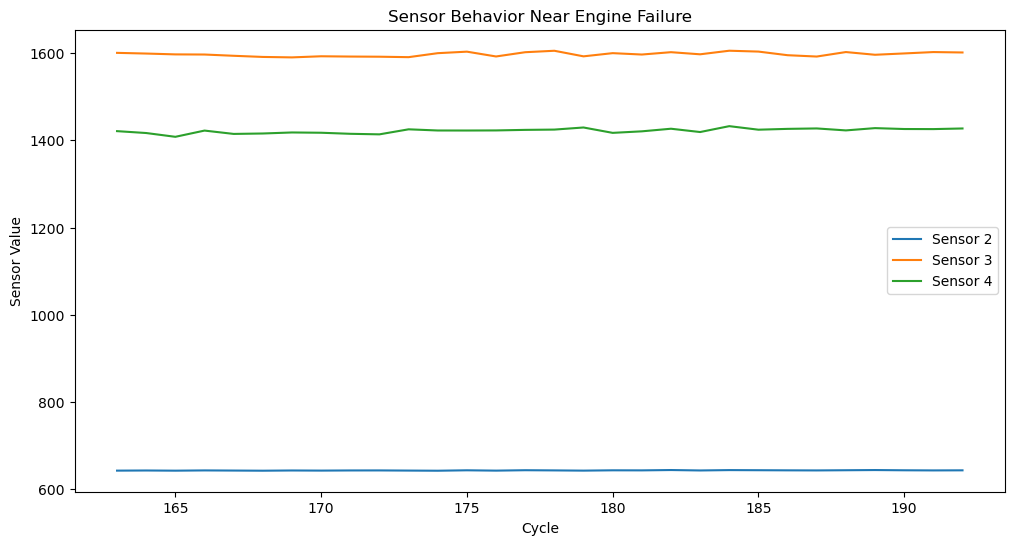

In [54]:
# This gives us an initial idea of whether sensor measurements change as failure approaches.
#This gives us an initial idea of whether sensor measurements change as failure approaches.
engine_1_last_30 = engine_1.tail(30)

plt.figure(figsize=(12, 6))

plt.plot(
    engine_1_last_30["cycle"],
    engine_1_last_30["sensor_2"],
    label="Sensor 2"
)

plt.plot(
    engine_1_last_30["cycle"],
    engine_1_last_30["sensor_3"],
    label="Sensor 3"
)

plt.plot(
    engine_1_last_30["cycle"],
    engine_1_last_30["sensor_4"],
    label="Sensor 4"
)

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor Behavior Near Engine Failure")

plt.legend()
plt.show()